
# Exploratory Data Analysis & Time-Series Analysis of SDSS Photometric Data

## Project Overview

This notebook focuses on the **Exploratory Data Analysis (EDA)** and **Time-Series Analysis** of astronomical objects from the Sloan Digital Sky Survey (SDSS) dataset. By profiling the dataset's structural composition and isolating the most frequently observed objects, the workflow implements robust data pipelines to extract and visualize light curves across five photometric bands ($u, g, r, i, z$).

---

## Key Methodology & Findings

* **Class Distribution:** An initial demographic analysis of the dataset shows a dominant population of Galaxies and Stars, with a smaller fraction of Quasars (QSOs).
* **Data Cleansing & Reshaping:** Time-series arrays were constructed by mapping the Modified Julian Date (`mjd`) into continuous datetime objects. Handling missing values (`NaN`) and anomalous indexing safeguarded the plotting pipeline against positional boundary errors during bulk comparative analysis.
* **Multi-band Correlational Profiling:** Employing Seaborn's `pairplot` with a Gaussian Kernel Density Estimate (`kde`) on the diagonal revealed deep statistical properties of the photometric variables.

---

## Deep-Dive: Behavior Analysis of Object `1237659326031200000`

The core discovery of this notebook lies in the physical behavior of a uniquely isolated highly-frequent object (`Objid: 1237659...`):

### 1. The Light Curve Anomaly (Time-Domain)

Upon plotting the chronological magnitude variations in the $r$-band, the object exhibits a generally stable brightness baseline punctuated by a **sudden, severe, and sharp drop in flux (a steep surge in magnitude)**. This drop approaches a localized minimum before recovering rapidly back to its baseline.

### 2. Perfect Photometric Coherence (Color-Space)

The `sns.pairplot` generated for this specific object uncovers a **perfect, tight linear correlation** among all five filters ($u, g, r, i, z$). The synchronous decline across all wavelengths simultaneously rules out observational noise, instrument calibration errors, or single-filter cosmic ray artifacts. Furthermore, the bimodal distribution in the diagonal density plots beautifully mirrors the brief, distinct epochs the system spends at the bottom of its eclipse.

### 3. Astrophysical Verdict

While the automated pipeline initially flagged the record as a `GALAXY`, its **spectroscopic redshift is nearly zero ($\approx -0.000$)**. This strongly suggests a stellar object residing inside our Milky Way galaxy.

Combining the sharp dip in the light curve with the flawless multi-band correlation, this data provides a textbook signature of an **Eclipsing Binary Star System**. The sudden dimming marks the primary eclipse when a companion star physically transits across our line of sight, blocking the primary star's light.

---

### 🚀 Future Scope

This notebook proves that combining simple Pythonic engineering (`pandas`, `seaborn`) with astronomical data can bypass automated classification flaws and flag significant variable targets for deeper astrophysical modeling. Future steps include applying Fourier transforms to estimate the orbital period of this binary system.

---



# 1. قراءة البيانات


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
df = pd.read_csv('Skyserver.csv')
df.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1237666301628060000,47.372545,0.820621,18.69254,17.13867,16.55555,16.34662,16.17639,4849,301,5,771,8168632633242440000,STAR,0.000115,7255,56597,832
1,1237673706652430000,116.303083,42.455980,18.47633,17.30546,17.24116,17.32780,17.37114,6573,301,6,220,9333948945297330000,STAR,-0.000093,8290,57364,868
2,1237671126974140000,172.756623,-8.785698,16.47714,15.31072,15.55971,15.72207,15.82471,5973,301,1,13,3221211255238850000,STAR,0.000165,2861,54583,42
3,1237665441518260000,201.224207,28.771290,18.63561,16.88346,16.09825,15.70987,15.43491,4649,301,3,121,2254061292459420000,GALAXY,0.058155,2002,53471,35
4,1237665441522840000,212.817222,26.625225,18.88325,17.87948,17.47037,17.17441,17.05235,4649,301,3,191,2390305906828010000,GALAXY,0.072210,2123,53793,74


# 2. تحويل التاريخ والترتيب زمنيّاً


In [81]:
df['date'] = pd.to_datetime(df['mjd'], unit='D', origin='1858-11-17')
df.set_index('date')
df.sort_values('date')

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid,date
51404,1237648722290280000,147.513095,0.719019,18.48396,16.76043,15.98171,15.60360,15.30425,756,301,5,212,300720305465223000,GALAXY,0.030943,267,51608,382,2000-03-05
9711,1237648720143190000,148.526411,-0.971684,18.49726,17.37068,16.97899,16.84624,16.80118,756,301,1,218,300628771122211000,STAR,0.000459,267,51608,49,2000-03-05
90642,1237650795146970000,147.722112,-0.691012,19.58351,18.30700,17.55432,17.15070,16.87822,1239,301,2,183,300673851098950000,GALAXY,0.138867,267,51608,213,2000-03-05
79965,1237651752922450000,147.675499,1.257339,17.86744,17.83661,18.22575,18.49767,18.74954,1462,301,2,149,300729926191966000,STAR,0.000176,267,51608,417,2000-03-05
40710,1237650797294580000,148.087274,0.970322,17.48645,15.51667,14.57325,14.10293,13.74994,1239,301,6,185,300761812029172000,GALAXY,0.047356,267,51608,533,2000-03-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19012,1237655502963340000,259.037836,30.321665,18.78160,17.81110,17.52403,17.41455,17.40082,2335,301,3,112,13121321770312600000,STAR,-0.000581,11654,58543,306,2019-03-01
75207,1237665128002880000,173.474356,34.034300,18.87128,17.89701,17.58058,17.46944,17.43437,4576,301,3,384,11554128748493400000,STAR,0.000403,10262,58543,523,2019-03-01
75720,1237651252060620000,260.250410,30.340698,18.24866,17.33558,17.02868,16.91228,16.86991,1345,301,5,740,13121264045952100000,STAR,-0.000086,11654,58543,96,2019-03-01
81715,1237665126929530000,174.522076,33.441686,17.99780,17.13643,16.89520,16.78248,16.79196,4576,301,1,390,11554072398522500000,STAR,0.000374,10262,58543,318,2019-03-01


# 3. الحل الذكي: عزل الجِرم الأكثر تكراراً في الملف (صاحب الـ 22 رصدة)


In [82]:
most_freq_stars = df['objid'].value_counts().index[0]
single_star = df[df['objid'] == most_freq_stars].copy()

# 4. حساب الفروقات ومؤشر اللون


C:\Users\MST\AppData\Local\Temp\ipykernel_7708\2766401680.py:1: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:skyblue'` for the same effect.

  sns.countplot(df , x='class', color='skyblue', hue='class')


<Axes: xlabel='class', ylabel='count'>

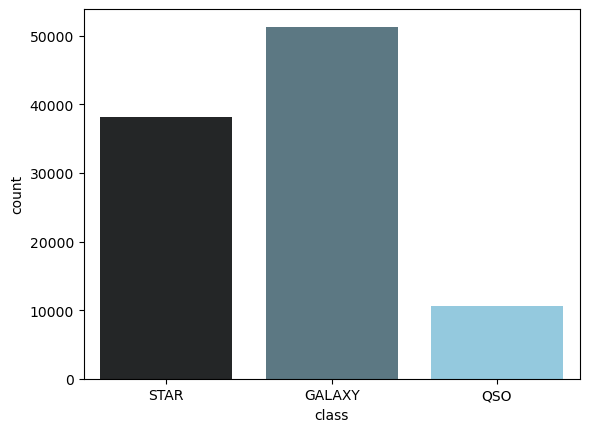

In [83]:
sns.countplot(df , x='class', color='skyblue', hue='class')

In [122]:
df['u-r-color'] = df['u'] - df['r']
df['u-r-color-log'] = np.log10(df['u-r-color'])
df['r-log'] = np.log10(df['r'])


C:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


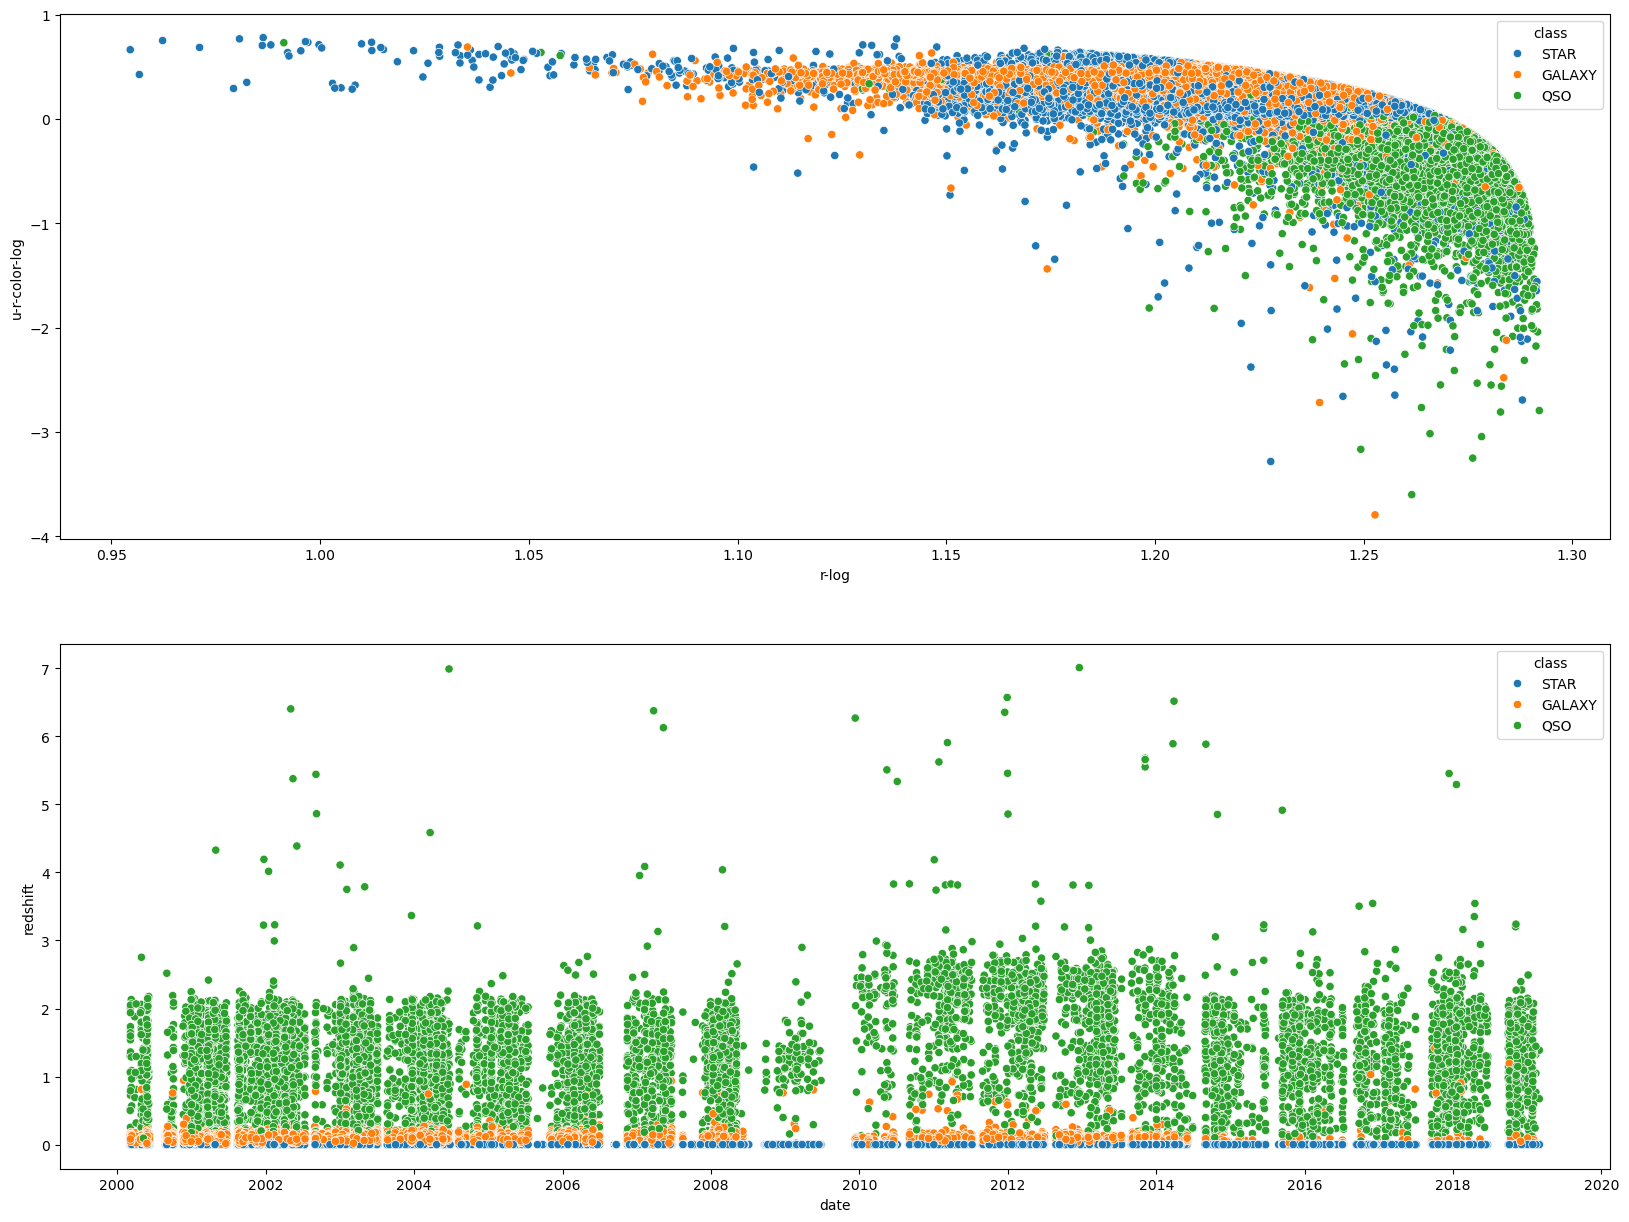

In [123]:
fig, ax = plt.subplots(2,1,figsize=(20,15))

sns.scatterplot(data=df, x="r-log", y="u-r-color-log",hue="class", ax= ax[0])
sns.scatterplot(data=df, x="date",y= "redshift", hue="class", ax= ax[1])
plt.show()


In [99]:
top_4_star = df['objid'].value_counts().index[:4]
print(top_4_star)

Index([1237657610727590000, 1237659326031200000, 1237665548887260000,
       1237661384387790000],
      dtype='int64', name='objid')


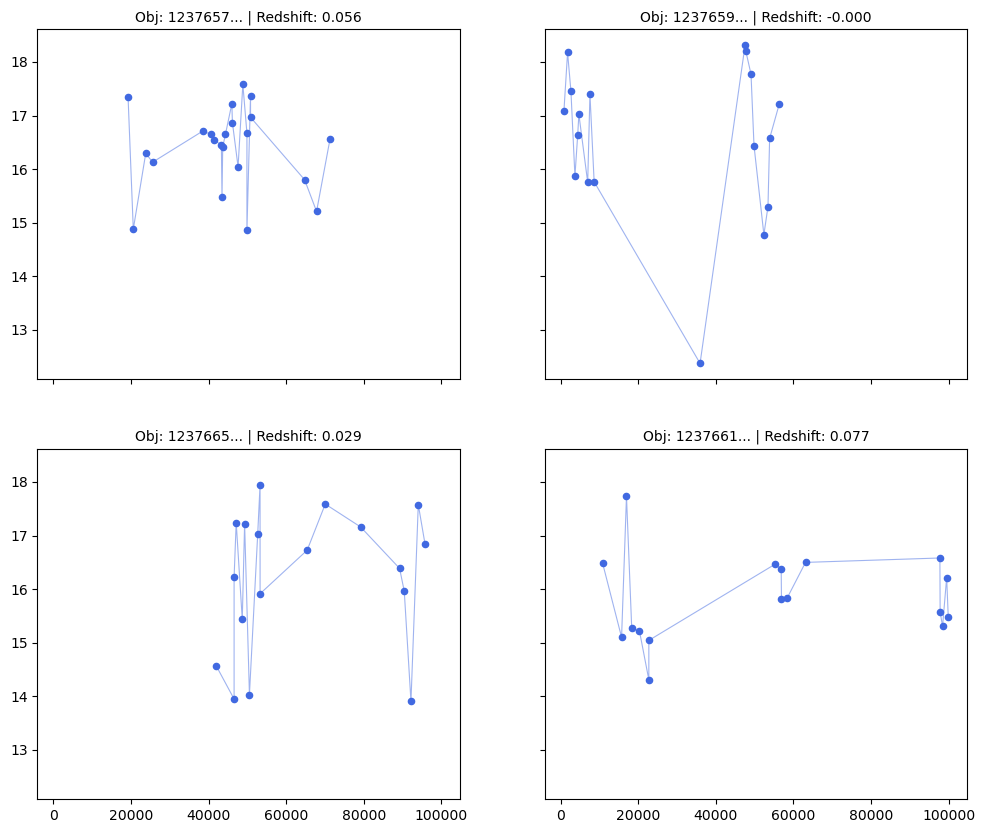

In [101]:
fig, ax = plt.subplots(2,2, figsize=(12,10), sharex=True, sharey=True)

# تحويل المصفوفة ثنائية الأبعاد (2,2) إلى قائمة أحادية (4 عناصر) لتسهيل المرور عليها بـ Loop
ax_flat = ax.flatten()

for i, obj_id in enumerate(top_4_star):
    star_data = df[df['objid'] == obj_id].dropna(subset=['r'])
    star_redshift = star_data['redshift'].iloc[0]
    ax_flat[i].plot(star_data.index, star_data['r'], color='royalblue', linewidth = 0.8, alpha= 0.5)
    ax_flat[i].scatter(star_data.index, star_data['r'], color='royalblue', s=20)
    
    #العناوين    
    ax_flat[i].set_title(f"Obj: {str(obj_id)[:7]}... | Redshift: {star_redshift:.3f}", fontsize=10)
    
    # عكس المحور الصادي فلكياً لأننا نرسم الـ Magnitude
    ax_flat[i].invert_yaxis()
  

In [112]:
this_star = df[df['objid'] == 1237659326031200000].sort_index()
features = ['u', 'g','r', 'i', 'z']



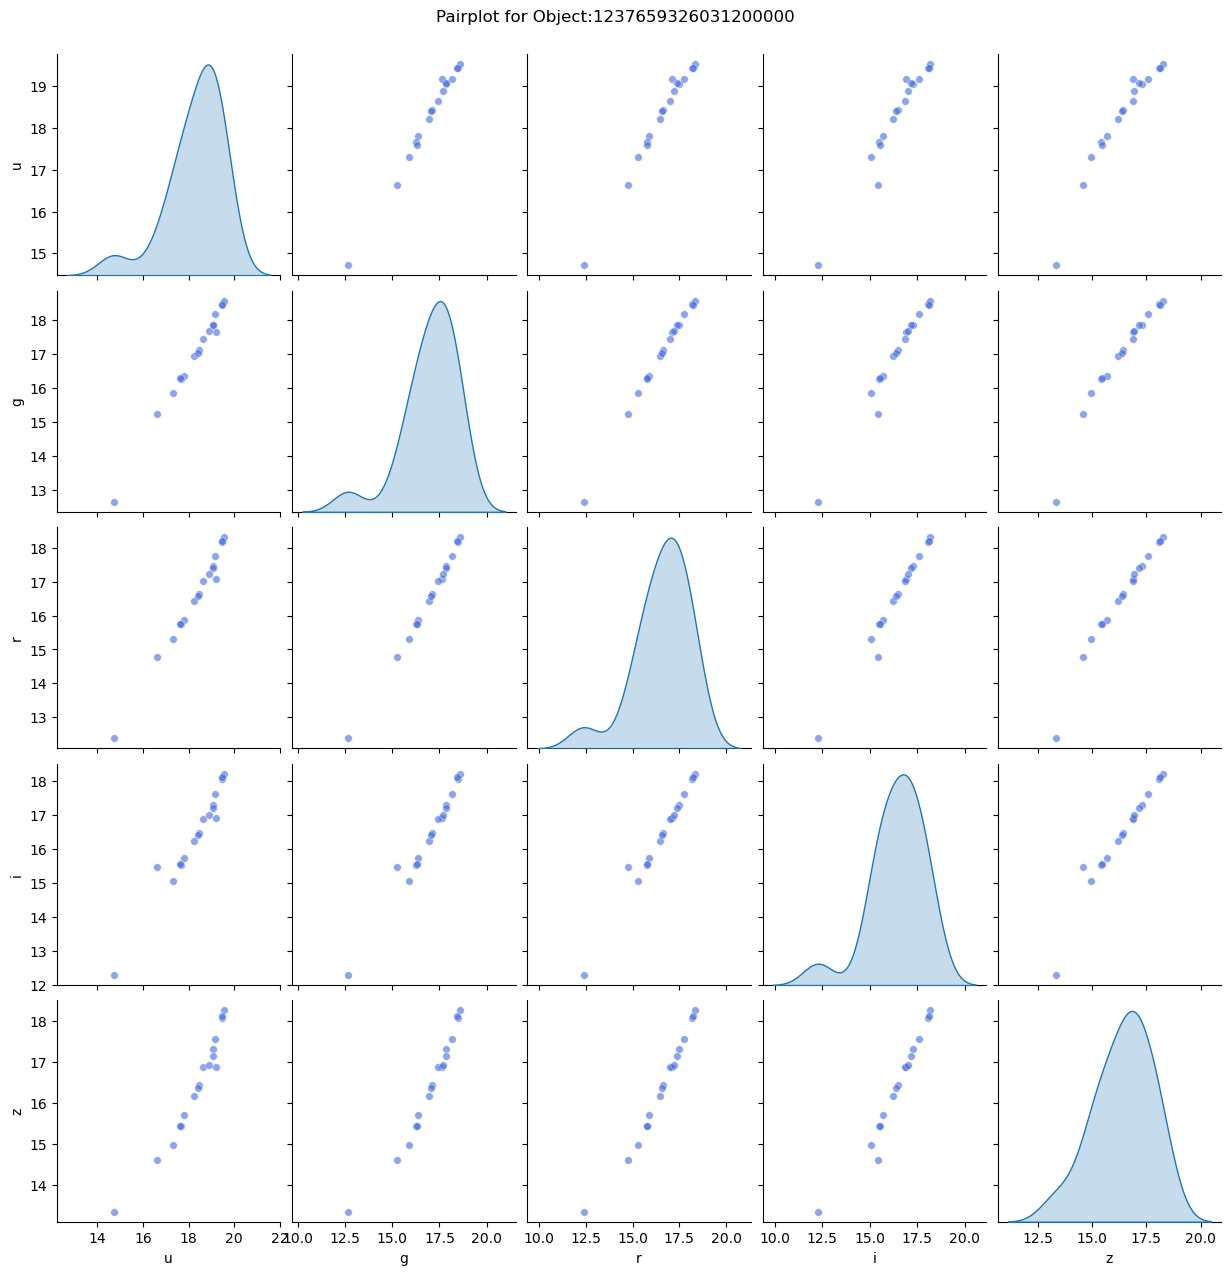

In [120]:
sns.pairplot(
    this_star[features],
    diag_kind= 'kde',
    plot_kws= {'alpha': 0.6, 'color': 'royalblue', 's' :30}
)
plt.suptitle(f"Pairplot for Object:{this_star['objid'].iloc[0]}", y= 1.02)
plt.show()